# Grup B — cahya/roberta-base-indonesian-1.5G (case-preserving), turunan S1 baseline

## Install dependency

In [ ]:
# Colab sudah punya transformers/datasets/torch — cukup upgrade
!pip install -q -U transformers accelerate seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 47.1 MB/s eta 0:00:00


In [ ]:
pip install tqdm -q

In [ ]:
pip install -U accelerate>=0.21.0' -q

/bin/bash: -c: line 1: unexpected EOF while looking for matching `''
/bin/bash: -c: line 2: syntax error: unexpected end of file


In [ ]:
pip install -U transformers[torch] -q

In [ ]:
pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 41.0 MB/s eta 0:00:00


In [ ]:
pip install seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=70d87d736efa8a9305ba8ec1c49763ee13943bdd49ceb929c6dc143000ee12e8
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


In [ ]:
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, TrainingArguments, Trainer, DataCollatorForTokenClassification, AutoModelForTokenClassification, pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_fscore_support
from shutil import rmtree
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

import os

# seqeval = entity-level NER metrics (fix G). Install once:  pip install seqeval
try:
    from seqeval.metrics import classification_report as seq_classification_report
    from seqeval.metrics import f1_score as seq_f1_score
    from seqeval.metrics import precision_score as seq_precision_score
    from seqeval.metrics import recall_score as seq_recall_score
    _HAS_SEQEVAL = True
except ImportError:
    _HAS_SEQEVAL = False
    print("[warn] seqeval tidak tersedia — jalankan `pip install seqeval` untuk metric entity-level")


## Load and prepare datasets

In [ ]:
os.getcwd()

'/content'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
_name = 'bert-only'
_type = 'sirah-ner'
experiment_name = f'{_name}-{_type}'

import os
# === Colab paths (Google Drive) ===
# Upload train.csv / test.csv / unlabelled.csv ke folder Drive berikut:
dataset_dir = '/content/drive/MyDrive/Genta/TA-Sirah'
root_dir    = '/content/drive/MyDrive/Genta/TA-Sirah/output_GrupB_roberta'
model_dir   = os.path.join(root_dir, 'models')
eval_dir    = os.path.join(root_dir, 'evaluation')
os.makedirs(model_dir, exist_ok=True)
os.makedirs(eval_dir,  exist_ok=True)


In [ ]:

df_train = pd.read_csv(os.path.join(dataset_dir, 'train.csv'))
df_train["token"] = df_train["token"].apply(str)
df_train["label"] = df_train["label"].apply(lambda x: x.replace("-", "_"))
df_train.loc[df_train[df_train.isna().any(axis=1)].index, 'token'] = 'nan'

In [ ]:
# === Smoke test: cek GPU & file ===
import torch, os
print("CUDA available :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU            :", torch.cuda.get_device_name(0))
else:
    print("!! GPU tidak aktif. Runtime > Change runtime type > T4 GPU")

for f in ['train.csv', 'test.csv', 'unlabelled.csv']:
    fp = os.path.join(dataset_dir, f)
    print(f"{f:<16} ->", 'OK' if os.path.exists(fp) else 'MISSING', fp)


CUDA available : True
GPU            : Tesla T4
train.csv        -> OK /content/drive/MyDrive/Genta/TA-Sirah/train.csv
test.csv         -> OK /content/drive/MyDrive/Genta/TA-Sirah/test.csv
unlabelled.csv   -> OK /content/drive/MyDrive/Genta/TA-Sirah/unlabelled.csv


In [ ]:
# # Cek indeks baris dengan NaN di kolom 'token'
# nan_token_indices = df_train[df_train["token"].isna()].index
# print("Indeks baris dengan NaN di kolom 'token':", nan_token_indices)

# # Cek indeks baris dengan NaN di kolom 'entity'
# nan_entity_indices = df_train[df_train["label"].isna()].index
# print("Indeks baris dengan NaN di kolom 'label':", nan_entity_indices)


In [ ]:
label_list = sorted(df_train['label'].unique(),key=lambda name: (name[1:], name[0]))
id2label = {i: label for i, label in enumerate(label_list)}
label2id = {v: k for k, v in id2label.items()}

id2label

{0: 'O',
 1: 'B_EVENT',
 2: 'I_EVENT',
 3: 'B_LOCATION',
 4: 'I_LOCATION',
 5: 'B_PERSON',
 6: 'I_PERSON',
 7: 'B_TIME',
 8: 'I_TIME'}

## Tokenize and split dataset into train and validation

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("cahya/roberta-base-indonesian-1.5G", model_max_length=512, add_prefix_space=True)

def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(examples['tokens'], truncation=True, is_split_into_words=True)

    labels = []
    for i, label in enumerate(examples['label']):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                label_ids.append(label[word_idx])
            else:
                label_ids.append(-100)
            previous_word_idx = word_idx
        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs


def df_to_dataset_for_model(df: pd.DataFrame, val_text_ids: list | None = None):
    """
    Preserves Bu Diana's logic (group by text_id → tokens list → label list → HF Dataset).

    FIX B: supports fixed validation split via `val_text_ids`.
    - If val_text_ids is None: falls back to random 80/20 (Bu Diana default).
    - If provided: val = text_ids in the list, train = everything else.
      This keeps the validation set stable across iterations so F1 val is comparable.
    """
    df = df.copy(deep=True)
    df["label"] = df["label"].fillna('O')
    df["label"] = df["label"].apply(lambda x: label2id[x])

    tmp_df = df.groupby("text_id")["token"].apply(list).reset_index()
    tmp_df["label"] = df.groupby("text_id")["label"].apply(list).reset_index()["label"]
    tmp_df.columns = ["text_id", "tokens", "label"]

    tmp_list = []
    for i in tmp_df.index:
        tmp_list.append({
            "text_id": tmp_df.loc[i, "text_id"],
            "tokens": tmp_df.loc[i, "tokens"],
            "label":  tmp_df.loc[i, "label"],
        })

    dataset = Dataset.from_list(tmp_list)

    tokenized_dataset = dataset.map(tokenize_and_align_labels,
                                    batched=True,
                                    remove_columns=[c for c in dataset.column_names if c != "text_id"])

    if val_text_ids is None:
        # Bu Diana default: random 80/20
        splits = tokenized_dataset.train_test_split(test_size=0.2, seed=42)
        train_val = DatasetDict({"train": splits["train"], "validation": splits["test"]})
    else:
        val_set  = set(map(str, val_text_ids))
        is_val   = [str(x) in val_set for x in tokenized_dataset["text_id"]]
        val_idx  = [i for i, v in enumerate(is_val) if v]
        trn_idx  = [i for i, v in enumerate(is_val) if not v]
        train_val = DatasetDict({
            "train":      tokenized_dataset.select(trn_idx).remove_columns(["text_id"]),
            "validation": tokenized_dataset.select(val_idx).remove_columns(["text_id"]),
        })

    return train_val


config.json:   0%|          | 0.00/556 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/926k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/468k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

In [ ]:
train_val = df_to_dataset_for_model(df_train)
print(train_val)

Map:   0%|          | 0/590 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text_id', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 472
    })
    validation: Dataset({
        features: ['text_id', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 118
    })
})


## Begin training base model

In [ ]:
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

def compute_metrics(pred):
    """Bu Diana: token-level weighted precision / recall / F1 (sklearn)."""
    labels = pred.label_ids
    preds = pred.predictions
    preds = preds[0] if isinstance(preds, tuple) else preds  # DistilBERT dll bisa balikin (logits, hidden_states)
    predictions = np.argmax(preds, axis=2)

    true_labels      = [[l for l, p in zip(label, prediction) if l != -100] for label, prediction in zip(labels, predictions)]
    true_predictions = [[p for l, p in zip(label, prediction) if l != -100] for label, prediction in zip(labels, predictions)]

    flat_true = [item for sub in true_labels      for item in sub]
    flat_pred = [item for sub in true_predictions for item in sub]

    precision, recall, f1, _ = precision_recall_fscore_support(
        flat_true, flat_pred, average='weighted', zero_division=0)

    out = {"precision": precision, "recall": recall, "f1": f1}

    # Fix G: entity-level seqeval metrics (used only for logging; Bu Diana's f1 stays as the 'best model' criterion)
    if _HAS_SEQEVAL:
        true_lbl = [[id2label[l] for l in seq] for seq in true_labels]
        pred_lbl = [[id2label[p] for p in seq] for seq in true_predictions]
        try:
            out["seq_f1"]        = seq_f1_score(true_lbl, pred_lbl)
            out["seq_precision"] = seq_precision_score(true_lbl, pred_lbl)
            out["seq_recall"]    = seq_recall_score(true_lbl, pred_lbl)
        except Exception:
            pass
    return out


def train_model(model_name: str,
                train_dataset: Dataset,
                val_dataset: Dataset,
                model_output_path: str,
                num_train_epochs: int = 10):

    training_args = TrainingArguments(
        output_dir=os.path.join(model_dir, "_trainer_tmp"),
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=num_train_epochs,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        seed=42,
    )

    def model_init():
        return AutoModelForTokenClassification.from_pretrained(model_name, id2label=id2label, label2id=label2id, output_hidden_states=False, output_attentions=False)

    trainer = Trainer(
        model_init=model_init,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    trainer.train()
    trainer.save_model(model_output_path)

    rmtree(os.path.join(model_dir, "_trainer_tmp"), ignore_errors=True)


In [ ]:
# --- BIO-aware decoder (Fix A) ---
# Bu Diana's labels are flat (ARG0, ARG1, ...), Sirah's are BIO (B_PERSON, I_PERSON, O).
# We auto-detect from id2label so the same function works in both schemes.
_BIO_SCHEME = any(str(lab).startswith(("B_", "I_")) for lab in id2label.values())


def extract_entities_from_result(tokens, result):
    """
    Map a list of whitespace-separated `tokens` to a list of labels using the
    HF NER pipeline output (`result` = list of {entity_group, start, end, score, word}).

    - Flat scheme (Bu Diana): returns `entity_group` directly (or "O").
    - BIO scheme (Sirah)  : returns `B_<entity_group>` on the first token inside
                             a span and `I_<entity_group>` on subsequent tokens.
    """
    predicted_entities = []
    current_index = 0
    prev_span_id = None

    for token in tokens:
        hit = None
        for idx, entry in enumerate(result):
            if entry["start"] <= current_index < entry["end"]:
                hit = idx
                break

        if hit is None:
            label = "O"
            prev_span_id = None
        else:
            group = result[hit]["entity_group"]
            if _BIO_SCHEME:
                # Two cases (Fix A2):
                # 1. Pipeline stripped BIO prefix (when labels used dash B-PERSON):
                #    group = "PERSON" -> infer B/I from span change
                # 2. Pipeline kept BIO prefix (when labels used underscore B_PERSON):
                #    group = "B_PERSON" or "I_PERSON" -> use directly
                if group.startswith(("B_", "I_")):
                    label = group
                else:
                    label = f"B_{group}" if hit != prev_span_id else f"I_{group}"
            else:
                label = group
            prev_span_id = hit

        predicted_entities.append(label)
        current_index += len(token) + 1  # +1 for the joining space

    return predicted_entities


def filter_threshold(model_path: str,
                     df: pd.DataFrame,
                     threshold: float,
                     output_dir: str,
                     output_filename_prefix: str,
                     sampling_rate: float = 1.0,
                     min_entity_confidence: float | None = None,
                     aggregation_strategy: str = "simple"):
    """
    Run NER on `df` (token-level: columns text_id, token), keep sentences whose
    average entity confidence passes `threshold`, return pseudo-labelled rows
    ready to concat with the seed (columns: text_id, token, label).

    Bu Diana's defaults are preserved:
        sampling_rate=1.0, min_entity_confidence=None, aggregation_strategy="simple".

    Optional improvements from analyticsvidhya pseudo-labelling guide:
      - sampling_rate (0,1]: keep only the top-K fraction of `above` sentences
        (ranked by avg confidence). E.g. 0.5 keeps the 50% most confident.
      - min_entity_confidence: reject a sentence unless *every* entity in it
        is ≥ this value (tighter than average-only).

    Also emits proper BIO labels in the retraining CSV when label scheme is BIO.
    """
    # cache: if retraining CSV already exists, reload and return
    cache_path = os.path.join(dataset_dir, f"{output_filename_prefix}-above-{threshold}-retraining.csv")
    if os.path.exists(cache_path):
        tmp_df = pd.read_csv(cache_path)
        tmp_df["token"] = tmp_df["token"].apply(str)
        return tmp_df

    ner = pipeline("token-classification",
                   model=model_path,
                   aggregation_strategy=aggregation_strategy)

    above = {'text_id': [], 'text': [], 'predicted_label': [], 'word': [], 'confidence': []}
    below = {'text_id': [], 'text': [], 'predicted_label': [], 'word': [], 'confidence': []}
    predicted_above_rows = []  # list of (text_id, tokens_list, labels_list, avg_score)

    text_ids = df["text_id"].unique().tolist()
    for text_id in tqdm(text_ids):
        tokens = df[df["text_id"] == text_id]["token"].astype(str).to_list()
        text = " ".join(tokens)
        result = ner(text)

        if len(result) == 0:
            below["text_id"].append(text_id)
            below["text"].append(text)
            below["predicted_label"].append("-")
            below["word"].append("-")
            below["confidence"].append(0)
            continue

        scores = [float(e["score"]) for e in result]
        avg = sum(scores) / len(scores)
        min_score = min(scores)

        # Fix C: reject whole sentence if any entity is below min_entity_confidence
        passes_min = (min_entity_confidence is None) or (min_score >= min_entity_confidence)

        if avg >= threshold and passes_min:
            predicted_above_rows.append((text_id, tokens,
                                         extract_entities_from_result(tokens, result),
                                         avg))
            for entity in result:
                above["text_id"].append(text_id)
                above["text"].append(text)
                above["predicted_label"].append(entity["entity_group"])
                above["word"].append(entity["word"])
                above["confidence"].append(entity["score"])
        else:
            for entity in result:
                below["text_id"].append(text_id)
                below["text"].append(text)
                below["predicted_label"].append(entity["entity_group"])
                below["word"].append(entity["word"])
                below["confidence"].append(entity["score"])

    # Fix E: sampling_rate — keep only the top-K fraction of above sentences by avg score
    if 0 < sampling_rate < 1.0 and predicted_above_rows:
        predicted_above_rows.sort(key=lambda r: r[3], reverse=True)
        keep = max(1, int(round(len(predicted_above_rows) * sampling_rate)))
        predicted_above_rows = predicted_above_rows[:keep]
        kept_ids = {r[0] for r in predicted_above_rows}
        # filter `above` dict to match
        above = {k: [v for v, tid in zip(vals, above["text_id"]) if tid in kept_ids]
                 for k, vals in above.items()}

    above_df = pd.DataFrame(above)
    below_df = pd.DataFrame(below)

    above_df.to_excel(os.path.join(output_dir, f"{output_filename_prefix}-above-{threshold}.xlsx"))
    below_df.to_excel(os.path.join(output_dir, f"{output_filename_prefix}-below-{threshold}.xlsx"))

    print(f"Above {threshold}: {len(above_df['text_id'].unique()) if len(above_df) else 0} sentences "
          f"(sampling_rate={sampling_rate}, min_entity_conf={min_entity_confidence})")
    print(f"Below {threshold}: {len(below_df['text_id'].unique()) if len(below_df) else 0} sentences")

    # Build retraining df: one row per token with predicted label (BIO-correct)
    retrain_rows = []
    for text_id, toks, labs, _avg in predicted_above_rows:
        for t, lab in zip(toks, labs):
            retrain_rows.append({"text_id": text_id, "token": t, "label": lab})
    retrain_df = pd.DataFrame(retrain_rows, columns=["text_id", "token", "label"])

    retrain_df.to_csv(cache_path, index=False)
    return retrain_df


def reconstruct_unlabelled_from_below(below_xlsx_path: str) -> pd.DataFrame:
    """
    Fix: Bu Diana's cell-29 trick (`rename word→token, drop_duplicates`) feeds
    the next iteration with disjoint entity words instead of the original
    sentences. This helper rebuilds the real token-level df from the `text`
    column (which is the full joined sentence per text_id).

    Convergence-safe: returns an empty DF with proper columns when the below
    file is empty (self-training converged, no more unlabelled to process).
    """
    df = pd.read_excel(below_xlsx_path)
    if len(df) == 0 or "text_id" not in df.columns:
        return pd.DataFrame(columns=["text_id", "token"])
    df = df.drop_duplicates(subset=["text_id"])[["text_id", "text"]].reset_index(drop=True)
    rows = []
    for _, r in df.iterrows():
        for tok in str(r["text"]).split():
            rows.append({"text_id": r["text_id"], "token": tok})
    return pd.DataFrame(rows, columns=["text_id", "token"])


## Iterative pseudo-labelling (threshold=0.9)

Blok di bawah menggantikan 6 pasang cell manual (predict → retrain) jadi satu for-loop,
dengan parameter yang bisa ditune sesuai panduan analyticsvidhya:

| Knob | Default (Bu Diana) | Alternatif |
|---|---|---|
| `N_ITERATIONS` | 6 | 3–10 |
| `THRESHOLD` | 0.9 | 0.85–0.95 |
| `SAMPLING_RATE` | 1.0 (pakai semua above) | 0.5 (pakai top-50%) |
| `MIN_ENTITY_CONF` | None | 0.85 (reject kalimat dgn entity ragu) |
| `MIN_NEW_SAMPLES` | 0 (no early stop) | 20–50 |
| `AGG_STRATEGY` | "simple" | "first" / "max" (sub-word clean) |

Output yang dihasilkan (sama persis struktur Bu Diana):
- `<prefix>-above-0.9.xlsx`, `<prefix>-below-0.9.xlsx` per iterasi
- `<prefix>-above-0.9-retraining.csv` per iterasi (sudah BIO-correct)
- `<experiment_name>-0.9-iteration-{2..N}/` folder model per iterasi
- `iteration_log.csv` — rekap jumlah above per iterasi (plot ini untuk laporan TA)


In [ ]:
import time as _t; _RT0 = _t.time()  # [runtime timer start]
# ============================================================
# Iterative pseudo-labelling loop (fixes D + E + F)
# ============================================================
# Preserves Bu Diana's flow:
#   iter 1: base model          → predict unlabelled → above_1, below_1 → retrain → iter-2 model
#   iter N: iter-N model        → predict below_{N-1} → above_N, below_N → retrain → iter-(N+1) model
#   iter LAST: only predict; no retrain after the last iteration
#
# Tunable knobs (defaults = Bu Diana):
#   N_ITERATIONS      : total predict rounds (6)
#   THRESHOLD         : confidence gate (0.9)
#   SAMPLING_RATE     : 1.0 = Bu Diana. Turunkan ke 0.5 untuk ikut saran analyticsvidhya.
#   MIN_ENTITY_CONF   : None = Bu Diana. Set ke 0.85 untuk reject kalimat dgn entity ragu.
#   MIN_NEW_SAMPLES   : 0 = no early stop. Set ke 20 untuk stop kalau model mulai jenuh.
#   AGG_STRATEGY      : "simple" = Bu Diana. "first" untuk sub-word clean.

N_ITERATIONS    = 6
THRESHOLD       = 0.9
SAMPLING_RATE   = 1.0
MIN_ENTITY_CONF = None
MIN_NEW_SAMPLES = 0
AGG_STRATEGY    = "simple"

# Stable validation split (fix B): seed text_ids only, fixed list
import random as _random
_seed_ids = sorted(df_train["text_id"].unique().tolist())
_rng = _random.Random(42)
_rng.shuffle(_seed_ids)
_n_val = max(1, int(round(len(_seed_ids) * 0.2)))
VAL_TEXT_IDS = _seed_ids[:_n_val]
print(f"[val split] {len(VAL_TEXT_IDS)} / {len(_seed_ids)} seed text_ids reserved for validation")

# Load unlabelled
df_unlabelled = pd.read_csv(os.path.join(dataset_dir, 'unlabelled.csv'))
df_unlabelled["token"] = df_unlabelled["token"].apply(str)

# Bootstrap: train base model on seed (with stable val split)
train_val_base = df_to_dataset_for_model(df_train, val_text_ids=VAL_TEXT_IDS)
print(train_val_base)

train_model(
    model_name="cahya/roberta-base-indonesian-1.5G",
    train_dataset=train_val_base["train"],
    val_dataset=train_val_base["validation"],
    model_output_path=os.path.join(model_dir, f"{experiment_name}-base"),
)

# Iterative loop
pseudo_dfs = []
iter_log = []
current_unlabelled = df_unlabelled
current_model_name = f"{experiment_name}-base"

for i in range(1, N_ITERATIONS + 1):
    if len(current_unlabelled) == 0:
        print(f"[iter {i}] no unlabelled chunks left -> STOP (self-training converged at iter {i-1})")
        break

    prev_model_path = os.path.join(model_dir, current_model_name)
    prefix = "bert-only-sirah-ner" if i == 1 else f"bert-only-sirah-ner-iterative-{i}"

    above_df = filter_threshold(
        model_path=prev_model_path,
        df=current_unlabelled,
        threshold=THRESHOLD,
        output_dir=eval_dir,
        output_filename_prefix=prefix,
        sampling_rate=SAMPLING_RATE,
        min_entity_confidence=MIN_ENTITY_CONF,
        aggregation_strategy=AGG_STRATEGY,
    )

    n_above = int(above_df["text_id"].nunique()) if len(above_df) else 0
    print(f"[iter {i}] above threshold: {n_above} sentences")
    iter_log.append({"iter": i, "n_above": n_above})

    if MIN_NEW_SAMPLES > 0 and n_above < MIN_NEW_SAMPLES:
        print(f"[iter {i}] early-stop: {n_above} < MIN_NEW_SAMPLES={MIN_NEW_SAMPLES}")
        break

    pseudo_dfs.append(above_df)

    # No retrain after the last iteration (matches Bu Diana)
    if i < N_ITERATIONS:
        new_model_name = f"{experiment_name}-0.9-iteration-{i+1}"
        combined = pd.concat([df_train] + pseudo_dfs, ignore_index=True)
        train_val_iter = df_to_dataset_for_model(combined, val_text_ids=VAL_TEXT_IDS)
        print(train_val_iter)

        train_model(
            model_name=prev_model_path,
            train_dataset=train_val_iter["train"],
            val_dataset=train_val_iter["validation"],
            model_output_path=os.path.join(model_dir, new_model_name),
        )
        current_model_name = new_model_name

        # Next-iter unlabelled = below-threshold sentences from this iter (real tokens, not the Bu-Diana rename trick)
        below_path = os.path.join(eval_dir, f"{prefix}-below-{THRESHOLD}.xlsx")
        current_unlabelled = reconstruct_unlabelled_from_below(below_path)

# Save iter log for reporting
pd.DataFrame(iter_log).to_csv(os.path.join(eval_dir, "iteration_log.csv"), index=False)
print("\nIteration log:")
print(pd.DataFrame(iter_log).to_string(index=False))

# Convenience aliases so downstream eval cells keep their variable names
final_iter = iter_log[-1]["iter"]
above_09_df = pseudo_dfs[0] if pseudo_dfs else pd.DataFrame()

# === [runtime timer] total blok training (download model pertama + semua iterasi self-training) ===
_RT = _t.time() - _RT0
print('[RUNTIME] skenario ini: %.2f menit (%.0f detik)' % (_RT/60, _RT))
try:
    with open(os.path.join(eval_dir, 'runtime_skenario.txt'), 'w') as _f:
        _f.write('runtime_detik=%.0f menit=%.2f' % (_RT, _RT/60))
    print('  runtime tersimpan ->', os.path.join(eval_dir, 'runtime_skenario.txt'))
except Exception as _e:
    print('  (gagal simpan runtime:', _e, ')')


[val split] 118 / 590 seed text_ids reserved for validation


Map:   0%|          | 0/590 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 472
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 118
    })
})


pytorch_model.bin:   0%|          | 0.00/504M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/504M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

100%|██████████| 30/30 [00:00<00:00, 30.36it/s]


Above 0.9: 11 sentences (sampling_rate=1.0, min_entity_conf=None)
Below 0.9: 19 sentences
[iter 6] above threshold: 11 sentences

Iteration log:
 iter  n_above
    1      125
    2       78
    3       11
    4        5
    5        1
    6       11
[RUNTIME] skenario ini: 60.33 menit (3620 detik)
  runtime tersimpan -> /content/drive/MyDrive/Genta/TA-Sirah/output_GrupB_roberta/evaluation/runtime_skenario.txt


## Evaluate model performance

In [ ]:
def get_predicted_label_on_test_dataset(model_path: str, df: pd.DataFrame):
  # Load model
  ner = pipeline("token-classification",
                 model=model_path,
                 aggregation_strategy="simple")

  predicted = []
  text_ids = df["text_id"].unique().tolist()

  for text_id in tqdm(text_ids):
    tokens = df[df["text_id"] == text_id]["token"].to_list()
    text = " ".join(tokens)
    result = ner(text)

    predicted.extend(extract_entities_from_result(tokens, result))

  df["predicted_label"] = predicted

def get_overall_performance(df: pd.DataFrame):
  # Overall accuracy
  total = len(df)
  correct = (df["label"] == df["predicted_label"]).sum()

  accuracy = (correct / total)

  print("Accuracy:", accuracy)

  # Precision, recall, and F1-score
  y_true = df['label']
  y_pred = df['predicted_label']

  precision = precision_score(y_true, y_pred, average='weighted', labels=label_list)
  recall = recall_score(y_true, y_pred, average='weighted', labels=label_list)
  f1 = f1_score(y_true, y_pred, average='weighted', labels=label_list)

  print("Precision:", precision)
  print("Recall:", recall)
  print("F1 Score:", f1)

def get_individual_label_score(df: pd.DataFrame):
  y_true = df['label']
  y_pred = df['predicted_label']

  report = classification_report(y_true, y_pred, labels=label_list, output_dict=True)
  return pd.DataFrame(report).transpose()

def get_confusion_matrix(df: pd.DataFrame):
  y_true = df['label']
  y_pred = df['predicted_label']

  cm = confusion_matrix(y_true, y_pred, labels=label_list)
  ax= plt.subplot()
  sns.heatmap(cm, annot=True, fmt='g', ax=ax, cmap="Oranges", vmin=0, vmax=160)  #annot=True to annotate cells, ftm='g' to disable scientific notation

  ax.set_xlabel('Predicted labels')
  ax.set_ylabel('True labels')
  ax.set_title('Confusion Matrix')
  plt.xticks(rotation=270)
  plt.yticks(rotation=0)
  ax.xaxis.set_ticklabels(label_list)
  ax.yaxis.set_ticklabels(label_list)

def get_misclassified_report(df: pd.DataFrame, output_path: str):

  misclassified_dict = {
      'text_id': [],
      'token': [],
      'true_label': [],
      'pred_label': [],
      'text': [],
  }

  for i in tqdm(df.index):
    true_label = df.loc[i, 'label']
    pred_label = df.loc[i, 'predicted_label']
    text_id = df.loc[i, 'text_id']

    if true_label != pred_label:
      misclassified_dict['token'].append(df.loc[i, 'token'])
      misclassified_dict['text_id'].append(text_id)
      misclassified_dict['true_label'].append(true_label)
      misclassified_dict['pred_label'].append(pred_label)
      misclassified_dict['text'].append(' '.join(df[df['text_id'] == text_id]['token'].to_list()))

  misclassified_df = pd.DataFrame.from_dict(misclassified_dict)
  misclassified_df.to_excel(output_path)

In [ ]:
def get_correct_and_incorrect_classification(df: pd.DataFrame, output_prefix: str):
  correct = {
      'text_id': [],
      'token': [],
      'true_label': [],
      'pred_label': [],
      'text': [],
  }

  incorrect = {
      'text_id': [],
      'token': [],
      'true_label': [],
      'pred_label': [],
      'text': [],
  }

  for i in tqdm(df.index):
    true_label = df.loc[i, 'label']
    pred_label = df.loc[i, 'predicted_label']
    text_id = df.loc[i, 'text_id']

    if true_label == pred_label:
      correct['token'].append(df.loc[i, 'token'])
      correct['text_id'].append(text_id)
      correct['true_label'].append(true_label)
      correct['pred_label'].append(pred_label)
      correct['text'].append(' '.join(df[df['text_id'] == text_id]['token'].to_list()))
    else:
      incorrect['token'].append(df.loc[i, 'token'])
      incorrect['text_id'].append(text_id)
      incorrect['true_label'].append(true_label)
      incorrect['pred_label'].append(pred_label)
      incorrect['text'].append(' '.join(df[df['text_id'] == text_id]['token'].to_list()))

  correct_df = pd.DataFrame.from_dict(correct)
  correct_df.to_excel(os.path.join(eval_dir, f"{output_prefix}-correct.xlsx"))

  incorrect_df = pd.DataFrame.from_dict(incorrect)
  incorrect_df.to_excel(os.path.join(eval_dir, f"{output_prefix}-incorrect.xlsx"))

In [ ]:
# === [PATCH] Auto-detect iterasi terakhir model yang tersimpan ===
# Self-training kadang stop early kalau n_above=0 (no pseudo-label baru di atas
# threshold). Hardcode `iteration-6` jadi error kalau file model tidak ada.
# Cell ini scan model_dir untuk find iter tertinggi yang valid.
import re

def _find_last_iteration(model_dir, experiment_name):
    """Returns int N for last `iteration-{N}` model directory yang exist."""
    pattern = re.compile(rf"^{re.escape(experiment_name)}-0\.9-iteration-(\d+)$")
    if not os.path.isdir(model_dir):
        return None
    iters = []
    for entry in os.listdir(model_dir):
        m = pattern.match(entry)
        if m:
            full_path = os.path.join(model_dir, entry)
            # Verify it's actually a model dir (has config.json)
            if os.path.exists(os.path.join(full_path, "config.json")):
                iters.append(int(m.group(1)))
    return max(iters) if iters else None

LAST_ITER = _find_last_iteration(model_dir, experiment_name)
if LAST_ITER is None:
    print(f"[WARN] No iteration-N model found in {model_dir}. Falling back to base model.")
    LAST_MODEL_PATH = os.path.join(model_dir, f"{experiment_name}-base")
    LAST_MODEL_TAG = "base"
else:
    LAST_MODEL_PATH = os.path.join(model_dir, f"{experiment_name}-0.9-iteration-{LAST_ITER}")
    LAST_MODEL_TAG = f"iterative-{LAST_ITER}"
    print(f"[OK] Last iteration found: {LAST_ITER}")
    print(f"     Model path: {LAST_MODEL_PATH}")
    print(f"     Tag       : {LAST_MODEL_TAG}")


[OK] Last iteration found: 6
     Model path: /content/drive/MyDrive/Genta/TA-Sirah/output_GrupB_roberta/models/bert-only-sirah-ner-0.9-iteration-6
     Tag       : iterative-6


In [ ]:
df_test = pd.read_csv(os.path.join(dataset_dir, "test.csv"))
df_test["label"] = df_test["label"].apply(lambda x: x.replace("-", "_"))

get_predicted_label_on_test_dataset(
    model_path=LAST_MODEL_PATH,
    df=df_test,
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

100%|██████████| 254/254 [00:11<00:00, 21.60it/s]


In [ ]:
get_overall_performance(df_test)
get_individual_label_score(df_test)

Accuracy: 0.9861677958945696
Precision: 0.9866245187145001
Recall: 0.9861677958945696
F1 Score: 0.9863372335831614


,precision,recall,f1-score,support
O,0.995713,0.993112,0.994411,46312.000000
B_EVENT,0.893333,0.917808,0.905405,73.000000
I_EVENT,0.838710,0.825397,0.832000,63.000000
B_LOCATION,0.906040,0.902004,0.904018,449.000000
I_LOCATION,0.896552,0.722222,0.800000,36.000000
B_PERSON,0.893667,0.889494,0.891576,1285.000000
I_PERSON,0.843014,0.907095,0.873881,1184.000000
B_TIME,0.731481,0.806122,0.766990,98.000000
I_TIME,0.773723,0.887029,0.826511,239.000000
accuracy,0.986168,0.986168,0.986168,0.986168


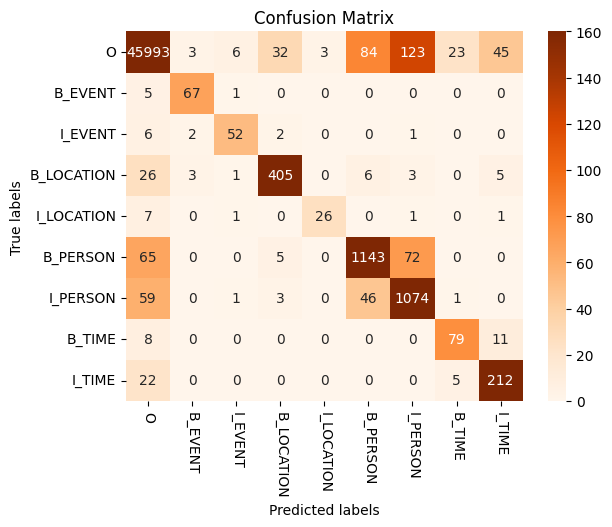

In [ ]:
get_confusion_matrix(df_test)

In [ ]:
get_misclassified_report(df_test, os.path.join(eval_dir, "bert-only-sirah-ner-confidence-0.9-misclassified.xlsx"))

100%|██████████| 49739/49739 [00:04<00:00, 11747.19it/s]


In [ ]:
get_correct_and_incorrect_classification(df_test, "bert-only-sirah-ner-iterative-6")

100%|██████████| 49739/49739 [04:04<00:00, 203.13it/s]


In [ ]:
df_test_base = pd.read_csv(os.path.join(dataset_dir, "test.csv"))
df_test_base["label"] = df_test_base["label"].apply(lambda x: x.replace("-", "_"))

get_predicted_label_on_test_dataset(
    model_path=os.path.join(model_dir , f"{experiment_name}-base"),
    df=df_test_base,
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

100%|██████████| 254/254 [00:07<00:00, 33.30it/s]


In [ ]:
get_overall_performance(df_test_base)
get_individual_label_score(df_test_base)

Accuracy: 0.9838557268943887
Precision: 0.9844466865702995
Recall: 0.9838557268943887
F1 Score: 0.9840616647463233


,precision,recall,f1-score,support
O,0.995040,0.991903,0.993469,46312.000000
B_EVENT,0.919355,0.780822,0.844444,73.000000
I_EVENT,0.763636,0.666667,0.711864,63.000000
B_LOCATION,0.909502,0.895323,0.902357,449.000000
I_LOCATION,0.880000,0.611111,0.721311,36.000000
B_PERSON,0.857784,0.891829,0.874475,1285.000000
I_PERSON,0.828729,0.886824,0.856793,1184.000000
B_TIME,0.706422,0.785714,0.743961,98.000000
I_TIME,0.732852,0.849372,0.786822,239.000000
accuracy,0.983856,0.983856,0.983856,0.983856
